In [1]:
!pip install pandas matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import display

In [3]:
base_dir = "."
plots_dir = os.path.join(base_dir, "plots")
summary_tables_dir = os.path.join(base_dir, "summary_tables")

os.makedirs(plots_dir, exist_ok=True)
os.makedirs(summary_tables_dir, exist_ok=True)

print("plots_dir:", plots_dir)
print("summary_tables_dir:", summary_tables_dir)

plots_dir: .\plots
summary_tables_dir: .\summary_tables


In [4]:
input_file = "../03_structured_data/structured_csv/dataset1_structured.csv"
df = pd.read_csv(input_file)

print("Rows:", len(df))
print(df.columns.tolist())
display(df.head())

Rows: 265
['query', 'video_id', 'title', 'channel', 'duration', 'view_count', 'upload_date', 'url', 'webpage_url', 'query_clean', 'title_clean', 'channel_clean', 'boundary_score', 'sound_score', 'noise_score', 'keep_initial', 'has_warning_term', 'has_territorial_term', 'has_distress_term', 'has_predator_term', 'has_urban_term', 'has_sound_term', 'sound_logic_group', 'boundary_logic_group', 'animal_type_hint', 'urban_reference', 'boundary_strength', 'matched_logic_terms', 'combined_text_for_vectorization']


,query,video_id,title,channel,duration,view_count,upload_date,url,webpage_url,query_clean,...,has_predator_term,has_urban_term,has_sound_term,sound_logic_group,boundary_logic_group,animal_type_hint,urban_reference,boundary_strength,matched_logic_terms,combined_text_for_vectorization
0,bird warning call,dvK-DujvpSY,White bellbird: listen to the world's loudest ...,Guardian News,31.0,9885069.0,NaN,https://www.youtube.com/watch?v=dvK-DujvpSY,NaN,bird warning call,...,False,False,True,warning_alarm,alerting_or_repelling,bird,urban_unspecified,medium,"call, warn, warning",bird warning call | white bellbird listen to t...
1,bird warning call,cPIIVjkp7k0,Bluebird Alarm Call,Wild Birds Unlimited Macomb,12.0,26065.0,NaN,https://www.youtube.com/watch?v=cPIIVjkp7k0,NaN,bird warning call,...,False,False,True,warning_alarm,alerting_or_repelling,bird,urban_unspecified,medium,"alarm, call, warn, warning",bird warning call | bluebird alarm call | warn...
2,bird warning call,ga_Ybn_K4rc,Chickadee alarm call (16 alarm call at the end!),Bird Feeder Hub,29.0,13511.0,NaN,https://www.youtube.com/watch?v=ga_Ybn_K4rc,NaN,bird warning call,...,False,False,True,warning_alarm,alerting_or_repelling,bird,urban_unspecified,medium,"alarm, call, warn, warning",bird warning call | chickadee alarm call 16 al...
3,bird warning call,uuxTZN98rHI,"5 bird alarm calls: blackbird, wren, blackcap,...",Watch the Birdie,96.0,30788.0,NaN,https://www.youtube.com/watch?v=uuxTZN98rHI,NaN,bird warning call,...,False,False,True,warning_alarm,alerting_or_repelling,bird,urban_unspecified,medium,"alarm, call, calls, warn, warning",bird warning call | 5 bird alarm calls blackbi...
4,bird warning call,2aFIujmqJfI,Bird Calls: Is That An Alarm?,NatureMentor,369.0,2894.0,NaN,https://www.youtube.com/watch?v=2aFIujmqJfI,NaN,bird warning call,...,False,False,True,warning_alarm,alerting_or_repelling,bird,urban_unspecified,medium,"alarm, call, calls, warn, warning",bird warning call | bird calls is that an alar...


In [5]:
summary_sound = df["sound_logic_group"].value_counts().reset_index()
summary_sound.columns = ["sound_logic_group", "count"]

summary_boundary = df["boundary_logic_group"].value_counts().reset_index()
summary_boundary.columns = ["boundary_logic_group", "count"]

summary_animal = df["animal_type_hint"].value_counts().reset_index()
summary_animal.columns = ["animal_type_hint", "count"]

summary_strength = df["boundary_strength"].value_counts().reset_index()
summary_strength.columns = ["boundary_strength", "count"]

summary_query = df["query"].value_counts().reset_index()
summary_query.columns = ["query", "count"]

summary_sound.to_csv(os.path.join(summary_tables_dir, "summary_sound_logic_group.csv"), index=False, encoding="utf-8-sig")
summary_boundary.to_csv(os.path.join(summary_tables_dir, "summary_boundary_logic_group.csv"), index=False, encoding="utf-8-sig")
summary_animal.to_csv(os.path.join(summary_tables_dir, "summary_animal_type_hint.csv"), index=False, encoding="utf-8-sig")
summary_strength.to_csv(os.path.join(summary_tables_dir, "summary_boundary_strength.csv"), index=False, encoding="utf-8-sig")
summary_query.to_csv(os.path.join(summary_tables_dir, "summary_query_distribution.csv"), index=False, encoding="utf-8-sig")

print("Saved summary tables.")

Saved summary tables.


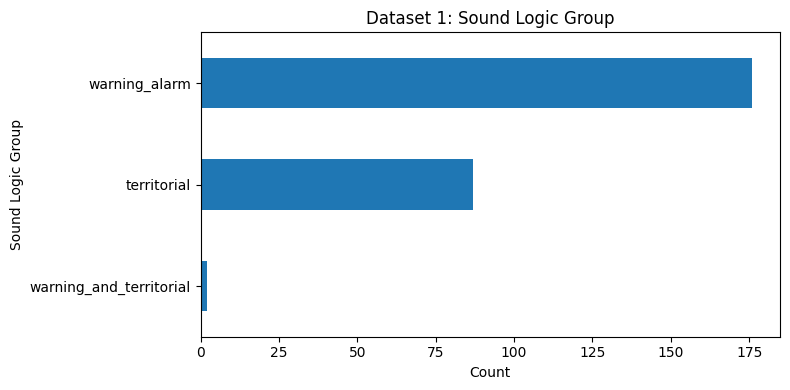

In [6]:
sound_counts = df["sound_logic_group"].value_counts().sort_values()

plt.figure(figsize=(8, 4))
sound_counts.plot(kind="barh")
plt.title("Dataset 1: Sound Logic Group")
plt.xlabel("Count")
plt.ylabel("Sound Logic Group")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "plot_01_sound_logic_group.png"), dpi=300)
plt.show()

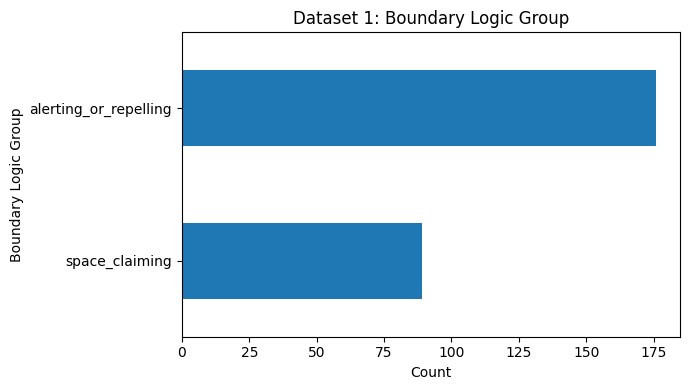

In [7]:
boundary_counts = df["boundary_logic_group"].value_counts().sort_values()

plt.figure(figsize=(7, 4))
boundary_counts.plot(kind="barh")
plt.title("Dataset 1: Boundary Logic Group")
plt.xlabel("Count")
plt.ylabel("Boundary Logic Group")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "plot_02_boundary_logic_group.png"), dpi=300)
plt.show()

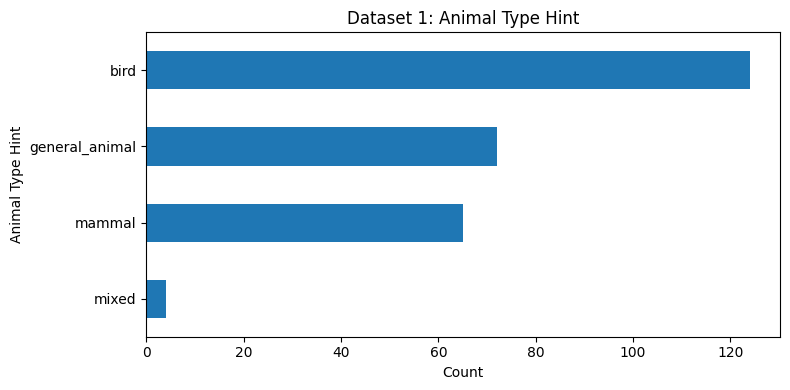

In [8]:
animal_counts = df["animal_type_hint"].value_counts().sort_values()

plt.figure(figsize=(8, 4))
animal_counts.plot(kind="barh")
plt.title("Dataset 1: Animal Type Hint")
plt.xlabel("Count")
plt.ylabel("Animal Type Hint")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "plot_03_animal_type_hint.png"), dpi=300)
plt.show()

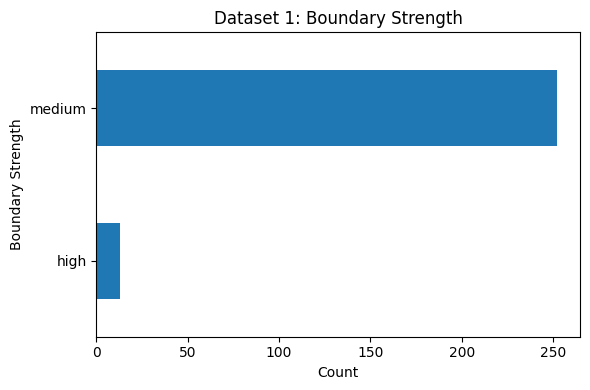

In [9]:
strength_counts = df["boundary_strength"].value_counts().sort_values()

plt.figure(figsize=(6, 4))
strength_counts.plot(kind="barh")
plt.title("Dataset 1: Boundary Strength")
plt.xlabel("Count")
plt.ylabel("Boundary Strength")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "plot_04_boundary_strength.png"), dpi=300)
plt.show()

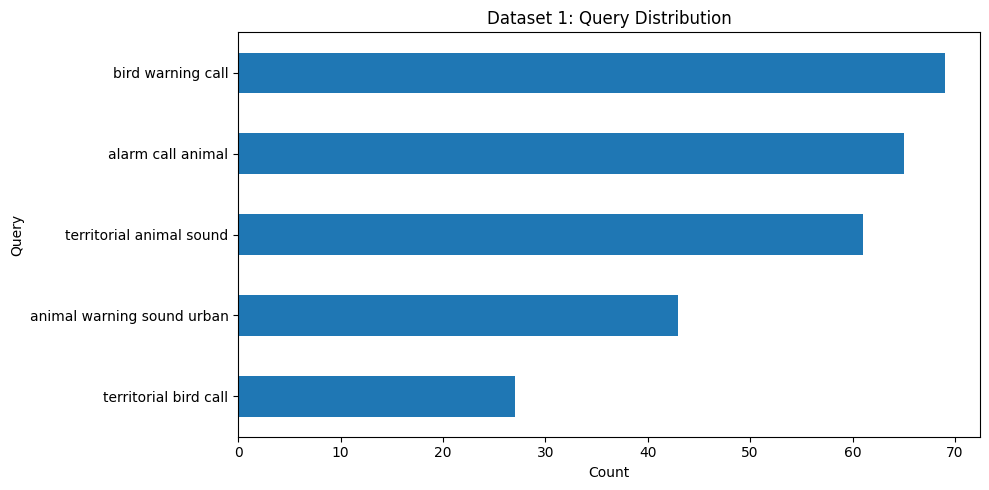

In [10]:
query_counts = df["query"].value_counts().sort_values()

plt.figure(figsize=(10, 5))
query_counts.plot(kind="barh")
plt.title("Dataset 1: Query Distribution")
plt.xlabel("Count")
plt.ylabel("Query")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "plot_05_query_distribution.png"), dpi=300)
plt.show()

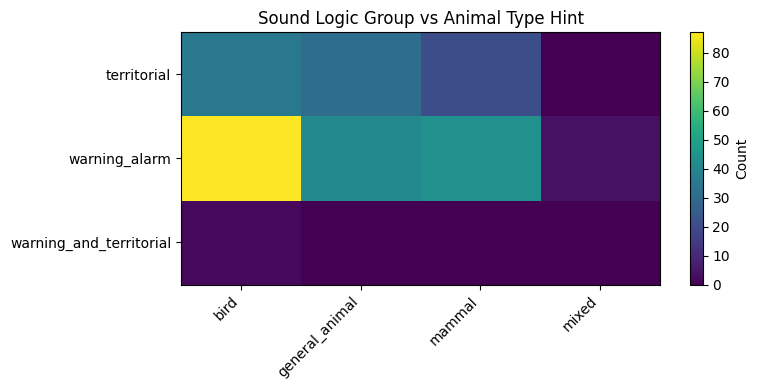

animal_type_hint,bird,general_animal,mammal,mixed
sound_logic_group,,,,
territorial,35,31,21,0
warning_alarm,87,41,44,4
warning_and_territorial,2,0,0,0


In [11]:
heatmap_1 = pd.crosstab(df["sound_logic_group"], df["animal_type_hint"])

plt.figure(figsize=(8, 4))
plt.imshow(heatmap_1, aspect="auto")
plt.colorbar(label="Count")
plt.xticks(range(len(heatmap_1.columns)), heatmap_1.columns, rotation=45, ha="right")
plt.yticks(range(len(heatmap_1.index)), heatmap_1.index)
plt.title("Sound Logic Group vs Animal Type Hint")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "plot_06_heatmap_soundlogic_animaltype.png"), dpi=300)
plt.show()

display(heatmap_1)

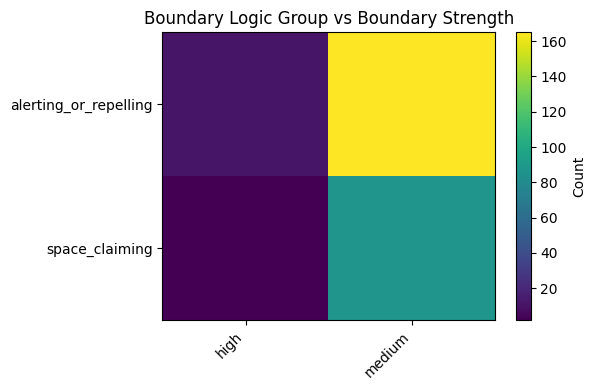

boundary_strength,high,medium
boundary_logic_group,,
alerting_or_repelling,11,165
space_claiming,2,87


In [12]:
heatmap_2 = pd.crosstab(df["boundary_logic_group"], df["boundary_strength"])

plt.figure(figsize=(6, 4))
plt.imshow(heatmap_2, aspect="auto")
plt.colorbar(label="Count")
plt.xticks(range(len(heatmap_2.columns)), heatmap_2.columns, rotation=45, ha="right")
plt.yticks(range(len(heatmap_2.index)), heatmap_2.index)
plt.title("Boundary Logic Group vs Boundary Strength")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "plot_07_heatmap_boundarylogic_strength.png"), dpi=300)
plt.show()

display(heatmap_2)

In [13]:
def split_terms(x):
    if pd.isna(x):
        return []
    return [i.strip() for i in str(x).split(",") if i.strip() != ""]

all_terms = []
for item in df["matched_logic_terms"]:
    all_terms.extend(split_terms(item))

term_counts = Counter(all_terms)
term_df = pd.DataFrame(term_counts.items(), columns=["term", "count"]).sort_values(
    by="count", ascending=False
)

display(term_df.head(20))

,term,count
0,call,178
5,sound,154
1,warn,114
2,warning,113
3,alarm,93
6,sounds,93
17,territorial,89
4,calls,50
23,urban,43
18,owl,9


In [14]:
term_df.to_csv(os.path.join(summary_tables_dir, "summary_matched_logic_terms.csv"), index=False, encoding="utf-8-sig")
print("Saved file: summary_matched_logic_terms.csv")

Saved file: summary_matched_logic_terms.csv


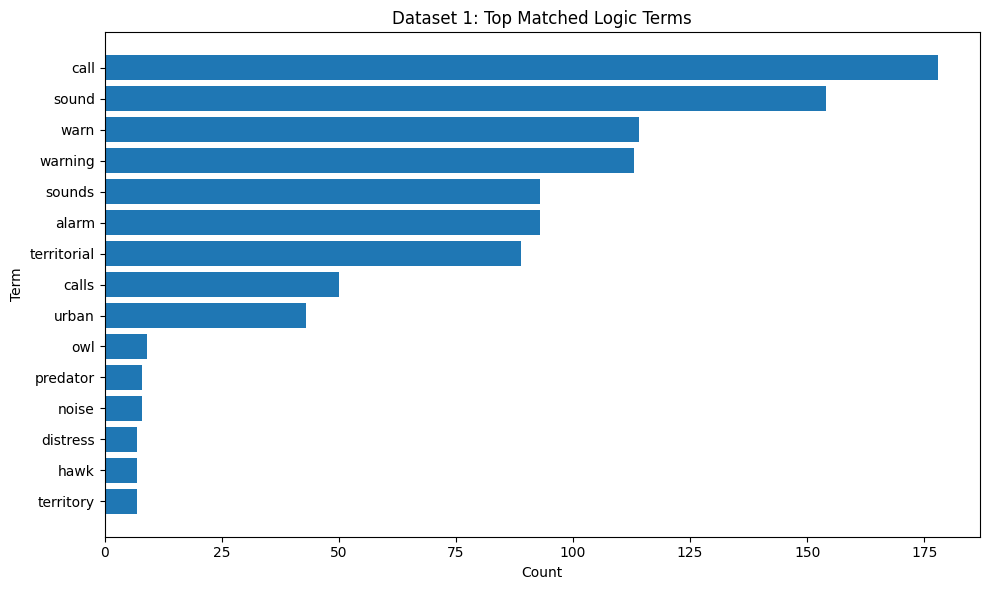

In [15]:
top_terms = term_df.head(15).sort_values(by="count")

plt.figure(figsize=(10, 6))
plt.barh(top_terms["term"], top_terms["count"])
plt.title("Dataset 1: Top Matched Logic Terms")
plt.xlabel("Count")
plt.ylabel("Term")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "plot_08_top_logic_terms.png"), dpi=300)
plt.show()

In [16]:
report_table = df[[
    "query",
    "title",
    "channel",
    "sound_logic_group",
    "boundary_logic_group",
    "animal_type_hint",
    "urban_reference",
    "boundary_strength",
    "matched_logic_terms",
    "combined_text_for_vectorization"
]].copy()

report_file = os.path.join(summary_tables_dir, "dataset1_report_table.csv")
report_table.to_csv(report_file, index=False, encoding="utf-8-sig")

print("Saved file:", report_file)
display(report_table.head())

Saved file: .\summary_tables\dataset1_report_table.csv


,query,title,channel,sound_logic_group,boundary_logic_group,animal_type_hint,urban_reference,boundary_strength,matched_logic_terms,combined_text_for_vectorization
0,bird warning call,White bellbird: listen to the world's loudest ...,Guardian News,warning_alarm,alerting_or_repelling,bird,urban_unspecified,medium,"call, warn, warning",bird warning call | white bellbird listen to t...
1,bird warning call,Bluebird Alarm Call,Wild Birds Unlimited Macomb,warning_alarm,alerting_or_repelling,bird,urban_unspecified,medium,"alarm, call, warn, warning",bird warning call | bluebird alarm call | warn...
2,bird warning call,Chickadee alarm call (16 alarm call at the end!),Bird Feeder Hub,warning_alarm,alerting_or_repelling,bird,urban_unspecified,medium,"alarm, call, warn, warning",bird warning call | chickadee alarm call 16 al...
3,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,...",Watch the Birdie,warning_alarm,alerting_or_repelling,bird,urban_unspecified,medium,"alarm, call, calls, warn, warning",bird warning call | 5 bird alarm calls blackbi...
4,bird warning call,Bird Calls: Is That An Alarm?,NatureMentor,warning_alarm,alerting_or_repelling,bird,urban_unspecified,medium,"alarm, call, calls, warn, warning",bird warning call | bird calls is that an alar...


In [17]:
print("Rows:", len(df))

print("\nSound logic group:")
print(df["sound_logic_group"].value_counts())

print("\nBoundary logic group:")
print(df["boundary_logic_group"].value_counts())

print("\nAnimal type hint:")
print(df["animal_type_hint"].value_counts())

print("\nBoundary strength:")
print(df["boundary_strength"].value_counts())

print("\nTop 10 matched logic terms:")
display(term_df.head(10))

Rows: 265

Sound logic group:
sound_logic_group
warning_alarm              176
territorial                 87
warning_and_territorial      2
Name: count, dtype: int64

Boundary logic group:
boundary_logic_group
alerting_or_repelling    176
space_claiming            89
Name: count, dtype: int64

Animal type hint:
animal_type_hint
bird              124
general_animal     72
mammal             65
mixed               4
Name: count, dtype: int64

Boundary strength:
boundary_strength
medium    252
high       13
Name: count, dtype: int64

Top 10 matched logic terms:


,term,count
0,call,178
5,sound,154
1,warn,114
2,warning,113
3,alarm,93
6,sounds,93
17,territorial,89
4,calls,50
23,urban,43
18,owl,9


In [18]:
display(df[[
    "query",
    "title",
    "sound_logic_group",
    "boundary_logic_group",
    "animal_type_hint",
    "boundary_strength"
]].sample(20, random_state=42))

,query,title,sound_logic_group,boundary_logic_group,animal_type_hint,boundary_strength
179,animal warning sound urban,Barking dogs and urban traffic sound effect,warning_alarm,alerting_or_repelling,mammal,medium
115,alarm call animal,"Alarm Calls, Crying Wolf, Referential & Affere...",warning_alarm,alerting_or_repelling,mammal,medium
96,alarm call animal,Monkeys Sound Alarm To Save Deer From A Tiger ...,warning_alarm,alerting_or_repelling,mammal,medium
24,bird warning call,Bird making Samsung notification sounds,warning_alarm,alerting_or_repelling,mixed,medium
9,bird warning call,Cardinal Bird-Calling Sounds promo,warning_alarm,alerting_or_repelling,bird,medium
139,alarm call animal,The Inconvenient Alarm Call,warning_alarm,alerting_or_repelling,general_animal,medium
255,territorial animal sound,A minor territorial dispute breaks out between...,territorial,space_claiming,mammal,medium
45,bird warning call,Predator Hunting Call - Distressed Woodpecker ...,warning_alarm,alerting_or_repelling,bird,high
185,animal warning sound urban,African Goose Honking - Is this how dinos soun...,warning_alarm,alerting_or_repelling,general_animal,medium
125,alarm call animal,Animal alarm calls of the Sri Lankan dry zone ...,warning_alarm,alerting_or_repelling,general_animal,medium
